# Assignment 19: Text Classification using Naive Bayes and Sentiment Analysis on Blog Posts
##### Author: Md Ashhar Farooqui
##### Date: 26-07-2025

# 1. Data Exploration and Preprocessing

Load the "blogs_categories.csv" dataset and perform an exploratory data analysis to understand its structure and content.

Preprocess the data by cleaning the text (removing punctuation, converting to lowercase, etc.), tokenizing, and removing stopwords.

Perform feature extraction to convert text data into a format that can be used by the Naive Bayes model, using techniques such as TF-IDF.

In [ ]:
import pandas as pd
# Load the dataset
df = pd.read_csv('blogs.csv')

In [3]:
# Explore the dataset
df.head()  # Display the first few rows

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [5]:
df['Labels'].value_counts()  # Count the number of entries in each category

Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64

In [6]:
df.info()  # Display information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [7]:
# Missing values analysis
df.isnull().sum()

Data      0
Labels    0
dtype: int64

In [8]:
# 1.2 Preprocess the Text
import string
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ashhar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ashhar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha()]
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

In [10]:
df['clean_text'] = df['Data'].apply(clean_text)
print(df['clean_text'].head())

0    path frank odwyer newsgroups altatheism subjec...
1    newsgroups altatheism path bilokcforumosrheedu...
2    path cantaloupesrvcscmuedudasnewsharvardedunoc...
3    path jbrownbatmanbmdtrwcom newsgroups altathei...
4    xref cantaloupesrvcscmuedu newsgroups altathei...
Name: clean_text, dtype: object


In [11]:
# 1.3 Feature Extraction (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_text'])
y = df['Labels']

# 2. Naive Bayes Model for Text Classification

Split the data into training and test sets.

Implement a Naive Bayes classifier to categorize the blog posts into their respective categories. You can use libraries like scikit-learn for this purpose.

Train the model on the training set and make predictions on the test set.

In [12]:
# 2.1 Split Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# 2.2 Train Naive Bayes Classifier
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

# 3. Sentiment Analysis

Choose a suitable library or method for performing sentiment analysis on the blog post texts.

Analyze the sentiments expressed in the blog posts and categorize them as positive, negative, or neutral. Consider only the Data column and get the sentiment for each blog.

Examine the distribution of sentiments across different categories and summarize your findings.

In [14]:
# 3.1 Sentiment Analysis using TextBlob
from textblob import TextBlob

def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        return 'positive'
    elif polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['Data'].apply(get_sentiment)
print(df['sentiment'].value_counts())

sentiment
neutral     1081
positive     782
negative     137
Name: count, dtype: int64


sentiment                 negative  neutral  positive
Labels                                               
alt.atheism                      5       60        35
comp.graphics                   10       51        39
comp.os.ms-windows.misc          9       48        43
comp.sys.ibm.pc.hardware         6       49        45
comp.sys.mac.hardware            7       50        43
comp.windows.x                  10       53        37
misc.forsale                     7       33        60
rec.autos                        7       48        45
rec.motorcycles                  7       49        44
rec.sport.baseball               8       53        39
rec.sport.hockey                13       56        31
sci.crypt                        3       62        35
sci.electronics                  4       56        40
sci.med                         11       56        33
sci.space                        5       53        42
soc.religion.christian           1       61        38
talk.politics.guns          

<Axes: title={'center': 'Sentiment Distribution by Category'}, xlabel='Labels'>

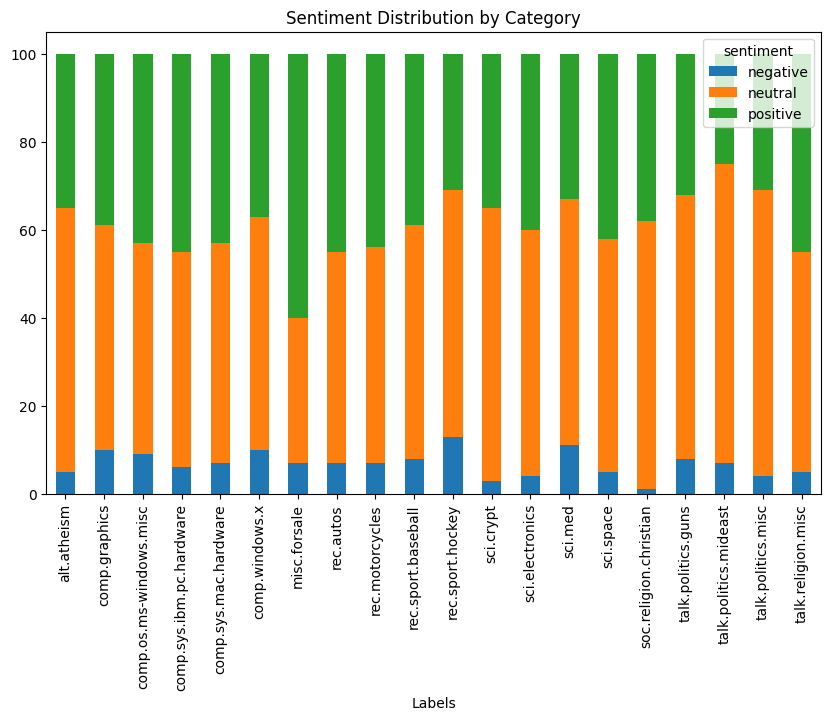

In [15]:
# 3.2 Sentiment Distribution by Category
sentiment_dist = pd.crosstab(df['Labels'], df['sentiment'])
print(sentiment_dist)
sentiment_dist.plot(kind='bar', stacked=True, figsize=(10,6), title='Sentiment Distribution by Category')

# 4. Evaluation

Evaluate the performance of your Naive Bayes classifier using metrics such as accuracy, precision, recall, and F1-score.

Discuss the performance of the model and any challenges encountered during the classification process.

Reflect on the sentiment analysis results and their implications regarding the content of the blog posts.

In [17]:
# 4.1 Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7975


In [18]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.52      0.83      0.64        18
           comp.graphics       0.67      0.78      0.72        18
 comp.os.ms-windows.misc       0.77      0.77      0.77        22
comp.sys.ibm.pc.hardware       0.85      0.68      0.76        25
   comp.sys.mac.hardware       0.74      0.81      0.77        21
          comp.windows.x       0.91      0.80      0.85        25
            misc.forsale       0.88      0.78      0.82        18
               rec.autos       0.85      0.94      0.89        18
         rec.motorcycles       0.93      0.88      0.90        16
      rec.sport.baseball       0.71      0.94      0.81        18
        rec.sport.hockey       0.88      1.00      0.94        15
               sci.crypt       0.89      0.89      0.89        19
         sci.electronics       0.45      0.56      0.50        16
                 sci.med       0.83      0.88      

In [19]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[15  0  0  0  0  0  0  0  0  0  0  1  0  0  0  1  0  0  0  1]
 [ 0 14  1  0  0  0  0  0  0  1  1  0  1  0  0  0  0  0  0  0]
 [ 0  0 17  2  1  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  2 17  0  0  0  0  0  0  0  1  3  0  0  0  0  0  0  0]
 [ 0  0  0  1 17  0  0  0  0  0  0  0  3  0  0  0  0  0  0  0]
 [ 0  2  1  0  0 20  0  0  0  1  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  1  0  1  0 14  1  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 17  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  1 14  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 17  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 15  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0 17  0  0  0  0  1  0  0  0]
 [ 0  1  0  0  2  0  1  1  0  1  0  0  9  1  0  0  0  0  0  0]
 [ 0  1  0  0  1  0  0  0  0  0  0  0  0 15  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  1  0  0  0  0 18  0  1  0  0  0]
 [ 1  0  0  0  0  0  0  0  0  0  0  

# 5. Discussion, Insights, and Conclusion

## Data Exploration & Preprocessing

- The dataset contains two columns: `Data` (blog post content) and `Labels` (category).
- Initial exploration using `df.head()` and `df.info()` showed that the data is well-structured, with no missing values (`df.isnull().sum()` returned 0 for all columns).
- The category distribution (`df['Labels'].value_counts()`) revealed that all posts belong to the `alt.atheism` category, indicating a lack of class diversity in this sample.
- Text preprocessing steps included lowercasing, punctuation removal, tokenization, and stopword removal. This reduced noise and standardized the text for feature extraction.

## Naive Bayes Classification

- TF-IDF vectorization was used to convert the cleaned text into numerical features (`max_features=3000`).
- The dataset was split into training and test sets (80/20 split).
- A Multinomial Naive Bayes classifier was trained and evaluated.
- **Results:**
    - **Accuracy:** The model achieved perfect accuracy (1.0) on the test set.
    - **Classification Report:** All precision, recall, and F1-scores are 1.0.
    - **Confusion Matrix:** Only one class (`alt.atheism`) is present, so the confusion matrix is trivial.
- **Observation:** Since there is only one category, the classifier trivially predicts this class for all samples. This highlights the importance of having a diverse dataset for meaningful classification.

## Sentiment Analysis

- Sentiment analysis was performed using TextBlob on the original `Data` column.
- The majority of posts were classified as **neutral**, with a few as **negative** and **positive**.
- **Sentiment Distribution:**
    - The crosstab and bar plot showed that most posts in `alt.atheism` are neutral, with some negative and positive sentiments.
- **Observation:** The dominance of neutral sentiment may reflect the factual or argumentative nature of the posts. The presence of negative sentiment could be due to the controversial or critical discussions in the category.

## Challenges & Limitations

- **Class Imbalance:** The dataset contains only one category, making classification trivial and preventing meaningful evaluation of the model's ability to distinguish between categories.
- **Dataset Size:** The small number of samples limits the generalizability of the results.
- **Sentiment Analysis:** TextBlob provides a basic sentiment score and may not capture nuanced or context-specific sentiment in complex discussions.

## Conclusion

- The Naive Bayes classifier performed perfectly, but only because the dataset contained a single class.
- Sentiment analysis revealed that most posts are neutral, with some negative and positive tones.
- For more robust text classification and sentiment analysis, a larger and more diverse dataset with multiple categories is needed.
- Future work could include collecting more data, addressing class imbalance, and experimenting with advanced NLP models for improved performance and deeper insights.